In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("../data/car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (301, 9)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 2


In [8]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

In [10]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.567887,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [11]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


Car_Name
['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' 'camry' 'land cruiser' 'Royal Enfield Thunder 500'
 'UM Renegade Mojave' 'KTM RC200' 'Bajaj Dominar 400'
 'Royal Enfield Classic 350' 'KTM RC390' 'Hyosung GT250R'
 'Royal Enfield Thunder 350' 'KTM 390 Duke ' 'Mahindra Mojo XT300'
 'Bajaj Pulsar RS200' 'Royal Enfield Bullet 350'
 'Royal Enfield Classic 500' 'Bajaj Avenger 220' 'Bajaj Avenger 150'
 'Honda CB Hornet 160R' 'Yamaha FZ S V 2.0' 'Yamaha FZ 16'
 'TVS Apache RTR 160' 'Bajaj Pulsar 150' 'Honda CBR 150' 'Hero Extreme'
 'Bajaj Avenger 220 dtsi' 'Bajaj Avenger 150 street' 'Yamaha FZ  v 2.0'
 'Bajaj Pulsar  NS 200' 'Bajaj Pulsar 220 F' 'TVS Apache RTR 180'
 'Hero Passion X pro' 'Bajaj Pulsar NS 200' 'Yamaha Fazer '
 'Honda Activa 4G' 'TVS Sport ' 'Honda Dream Yuga '
 'Bajaj Avenger Street 220' 'H

In [12]:
df.to_csv("../data/car_data_cleaned.csv", index=False)

PHASE - 2

In [13]:
plt.style.use('ggplot')

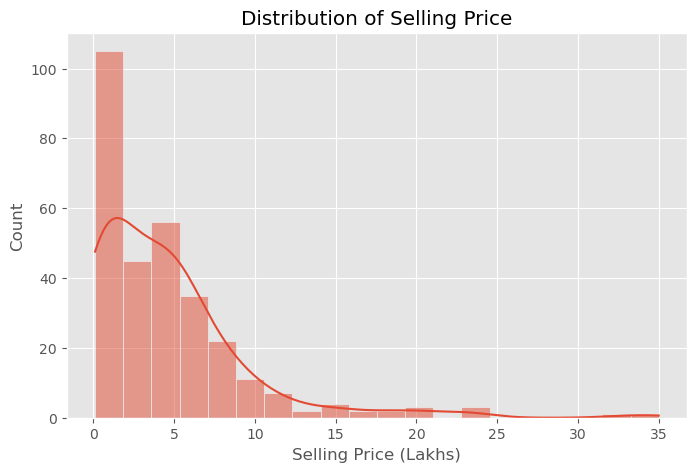

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Selling_Price'], bins=20, kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Count")

plt.show()

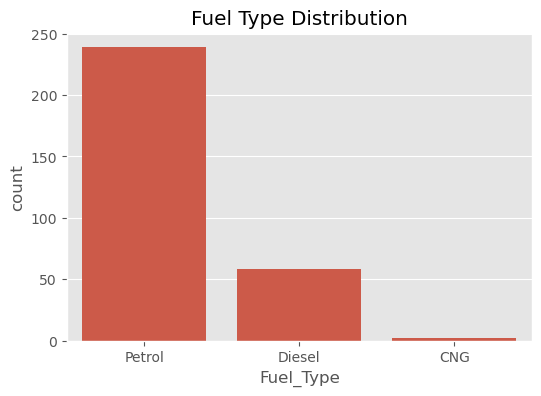

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x='Fuel_Type', data=df)

plt.title("Fuel Type Distribution")

plt.show()

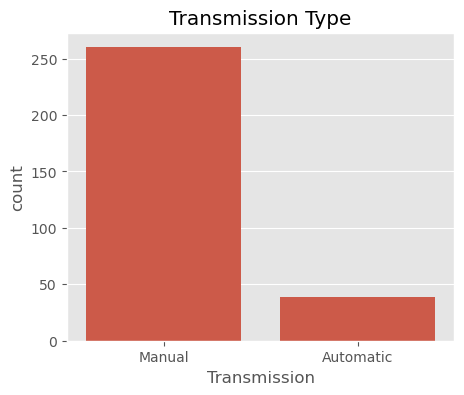

In [16]:
plt.figure(figsize=(5,4))

sns.countplot(x='Transmission', data=df)

plt.title("Transmission Type")

plt.show()

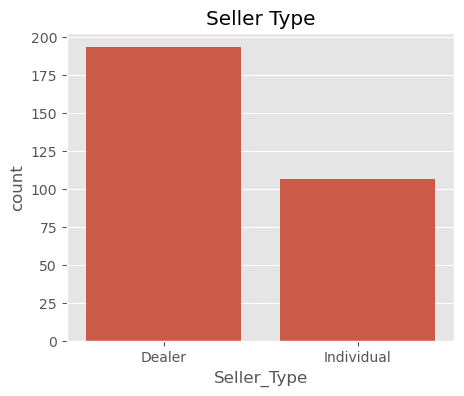

In [17]:
plt.figure(figsize=(5,4))

sns.countplot(x='Seller_Type', data=df)

plt.title("Seller Type")

plt.show()

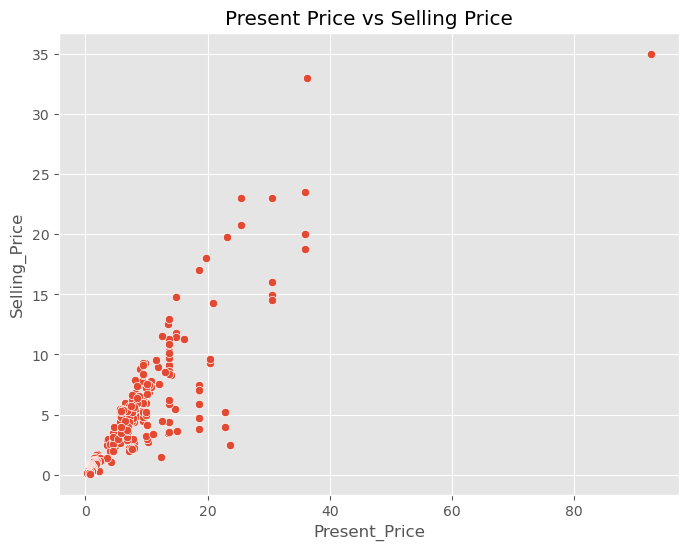

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Present_Price',
    y='Selling_Price',
    data=df
)

plt.title("Present Price vs Selling Price")

plt.show()

In [19]:
df_heatmap = df.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Fuel_Type','Seller_Type','Transmission']:
    df_heatmap[col] = le.fit_transform(df_heatmap[col])

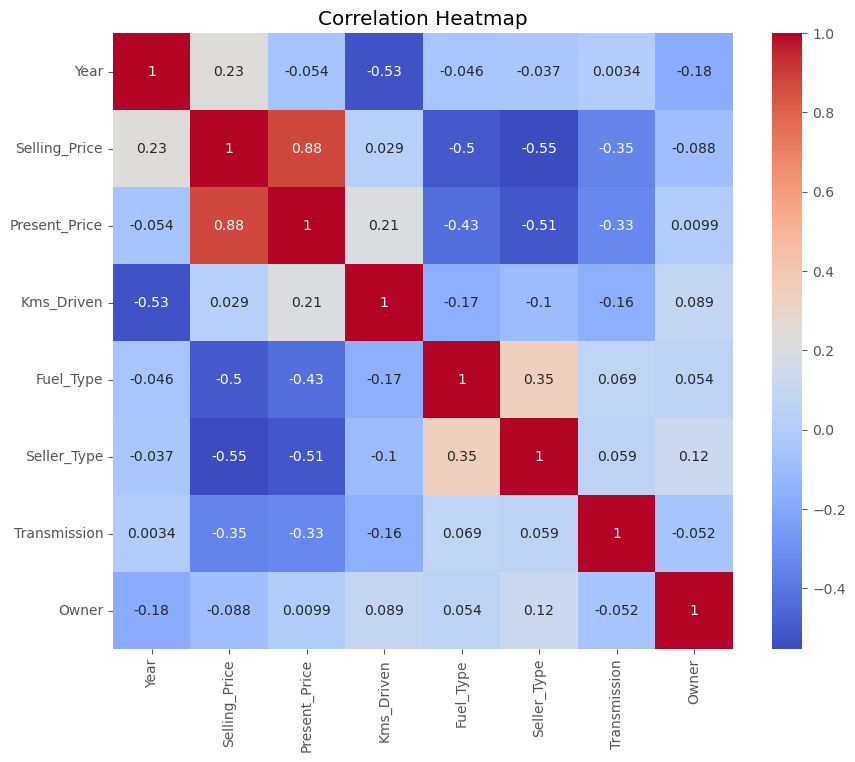

In [20]:
df_heatmap = df.copy()

df_heatmap = df_heatmap.drop('Car_Name', axis=1)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Fuel_Type', 'Seller_Type', 'Transmission']:
    df_heatmap[col] = le.fit_transform(df_heatmap[col])

plt.figure(figsize=(10,8))

sns.heatmap(
    df_heatmap.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

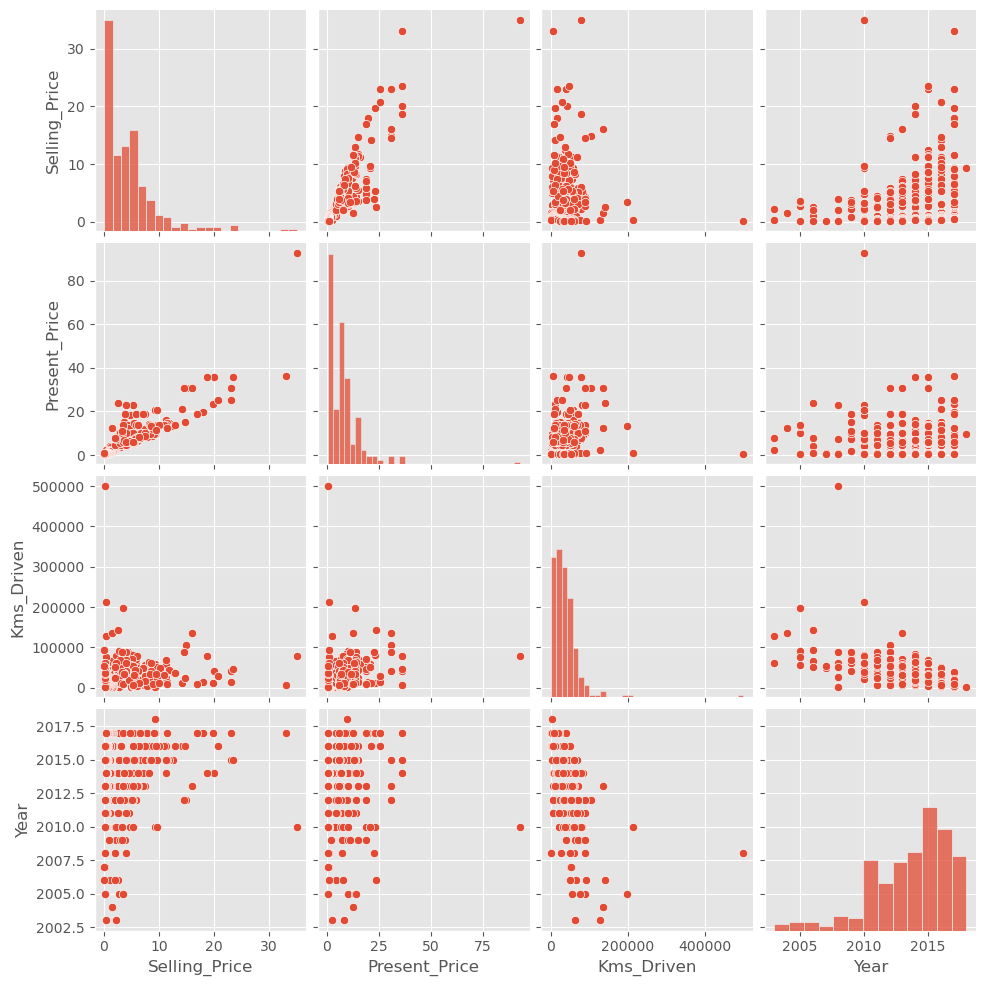

In [21]:
sns.pairplot(df[['Selling_Price',
                 'Present_Price',
                 'Kms_Driven',
                 'Year']])

plt.show()

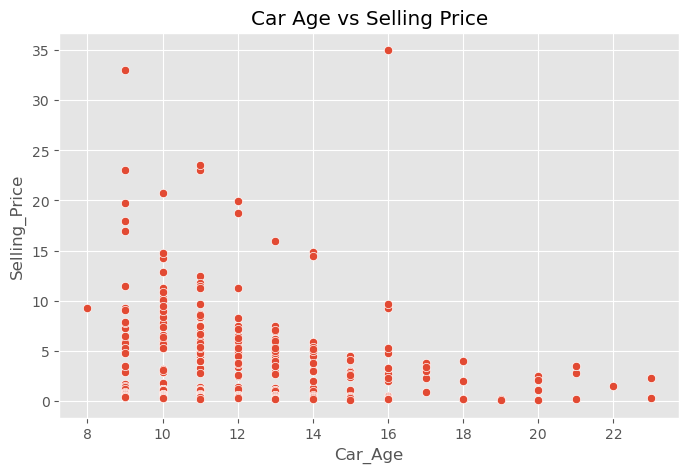

In [22]:
df['Car_Age'] = 2026 - df['Year']



plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Car_Age',
    y='Selling_Price',
    data=df
)

plt.title("Car Age vs Selling Price")

plt.show()


# Phase 3: Data Preprocessing & Feature Engineering


In [23]:
df_ml = df.copy()

df_ml.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [24]:
df_ml.drop(['Car_Name','Year'], axis=1, inplace=True)

df_ml.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [25]:
print(df_ml.columns)

Index(['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner', 'Car_Age'],
      dtype='object')


In [26]:
df_ml = pd.get_dummies(
    df_ml,
    columns=['Fuel_Type', 'Seller_Type', 'Transmission'],
    drop_first=True
)

df_ml.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


In [27]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Selling_Price           299 non-null    float64
 1   Present_Price           299 non-null    float64
 2   Kms_Driven              299 non-null    int64  
 3   Owner                   299 non-null    int64  
 4   Car_Age                 299 non-null    int64  
 5   Fuel_Type_Diesel        299 non-null    bool   
 6   Fuel_Type_Petrol        299 non-null    bool   
 7   Seller_Type_Individual  299 non-null    bool   
 8   Transmission_Manual     299 non-null    bool   
dtypes: bool(4), float64(2), int64(3)
memory usage: 15.2 KB


In [28]:
X = df_ml.drop("Selling_Price", axis=1)

y = df_ml["Selling_Price"]

In [29]:
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (299, 8)
Target Shape : (299,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [31]:
print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Data : (239, 8)
Testing Data : (60, 8)
Training Target : (239,)
Testing Target : (60,)


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [33]:
print(X_train_scaled[:5])

[[ 0.0792308  -0.55609426 -0.17370208 -0.46310243 -0.48162097  0.48820279
  -0.73616267  0.386055  ]
 [-0.77591555 -1.1560003  -0.17370208  1.97328237 -0.48162097  0.48820279
   1.35839541 -2.5903045 ]
 [-0.78385457 -0.08727564 -0.17370208  0.23300751 -0.48162097  0.48820279
   1.35839541  0.386055  ]
 [-0.73508628  0.37429979 -0.17370208  1.27717243 -0.48162097  0.48820279
   1.35839541  0.386055  ]
 [-0.28709847  0.70095318 -0.17370208  0.92911746 -0.48162097  0.48820279
  -0.73616267  0.386055  ]]


In [34]:
df_ml.to_csv("../data/car_data_preprocessed.csv", index=False)


# Phase 4: Model Building


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [36]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
lr_pred = lr.predict(X_test_scaled)

In [38]:
mae = mean_absolute_error(y_test, lr_pred)

mse = mean_squared_error(y_test, lr_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

Linear Regression Results
-------------------------
MAE : 1.4728924140032913
MSE : 6.3707529568232415
RMSE : 2.5240350545947736
R2 Score : 0.752815421583293


In [39]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [40]:
dt_pred = dt.predict(X_test)

In [41]:
mae_dt = mean_absolute_error(y_test, dt_pred)

mse_dt = mean_squared_error(y_test, dt_pred)

rmse_dt = np.sqrt(mse_dt)

r2_dt = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("-------------------------")
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE :", rmse_dt)
print("R2 Score :", r2_dt)

Decision Tree Results
-------------------------
MAE : 1.333333333333333
MSE : 8.502256666666668
RMSE : 2.91586293687935
R2 Score : 0.6701132905350315


In [42]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
rf_pred = rf.predict(X_test)

In [44]:
mae_rf = mean_absolute_error(y_test, rf_pred)

mse_rf = mean_squared_error(y_test, rf_pred)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("-------------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE :", rmse_rf)
print("R2 Score :", r2_rf)

Random Forest Results
-------------------------
MAE : 1.437946666666668
MSE : 11.665224829666673
RMSE : 3.4154391854733226
R2 Score : 0.547390441726516


In [45]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        mae_dt,
        mae_rf
    ],
    "RMSE": [
        rmse,
        rmse_dt,
        rmse_rf
    ],
    "R2 Score": [
        r2,
        r2_dt,
        r2_rf
    ]
})


In [46]:
results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.472892,2.524035,0.752815
1,Decision Tree,1.333333,2.915863,0.670113
2,Random Forest,1.437947,3.415439,0.547390



Phase 5: Model Evaluation & Visualization


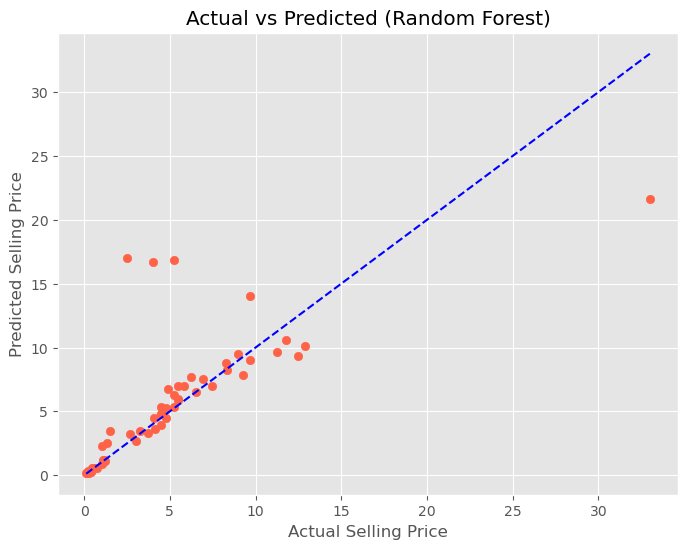

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred, color='tomato')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='blue',
    linestyle='--'
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted (Random Forest)")

plt.show()

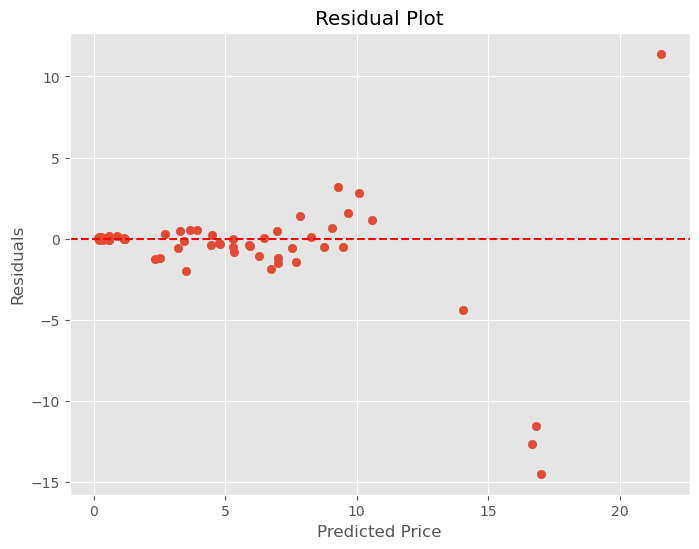

In [48]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,6))

plt.scatter(rf_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [49]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,Present_Price,0.905623
3,Car_Age,0.071841
1,Kms_Driven,0.013396
7,Transmission_Manual,0.005249
6,Seller_Type_Individual,0.002081
5,Fuel_Type_Petrol,0.000914
4,Fuel_Type_Diesel,0.000886
2,Owner,0.000010


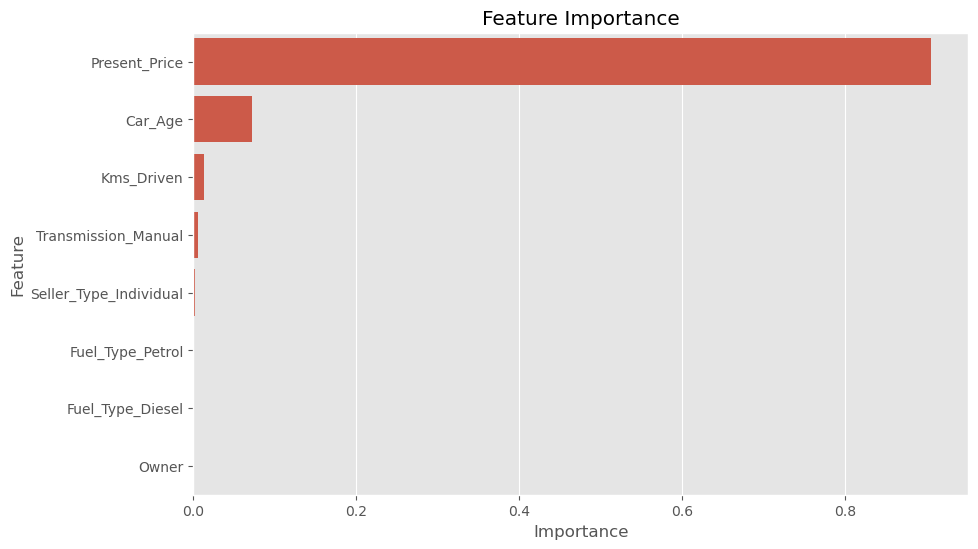

In [50]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

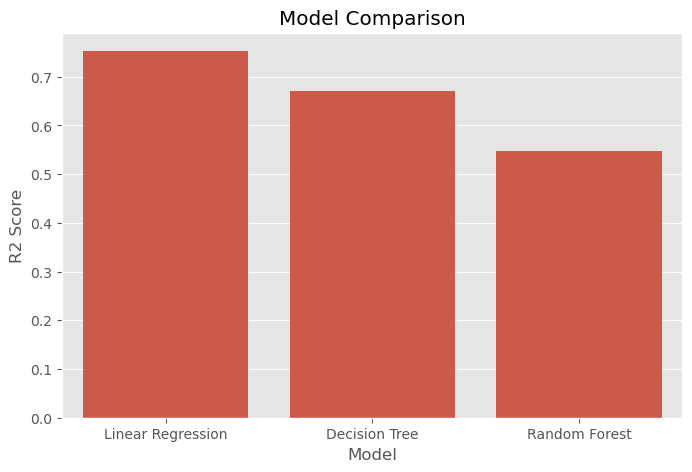

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title("Model Comparison")

plt.show()

In [52]:
import joblib

joblib.dump(rf, "../data/car_price_model.pkl")

['../data/car_price_model.pkl']

In [53]:
joblib.dump(scaler, "../data/scaler.pkl")

['../data/scaler.pkl']

In [54]:
import os

print(os.listdir("../data"))

['car data.csv', 'car_data_cleaned.csv', 'car_data_preprocessed.csv', 'car_price_model.pkl', 'scaler.pkl']



Phase 6 – Hyperparameter Tuning (Recommende)


In [55]:
from sklearn.model_selection import GridSearchCV

In [56]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [57]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

In [58]:
#training the model using grid search

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [59]:
print(grid_search.best_params_)
#best parameters found by grid search

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [60]:
#best socre
print(grid_search.best_score_)

0.8813556486725037


In [61]:
#best model
best_rf = grid_search.best_estimator_

In [62]:
#prediction
best_pred = best_rf.predict(X_test)

In [63]:
#ealuate
print("R2 Score :", r2_score(y_test, best_pred))
print("MAE :", mean_absolute_error(y_test, best_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, best_pred)))

R2 Score : 0.5948782649955546
MAE : 1.3745983589766706
RMSE : 3.2313013954428937


In [64]:
joblib.dump(best_rf, "../data/best_car_price_model.pkl")

#save optimized model

['../data/best_car_price_model.pkl']


Phase 7: Final Model Evaluation


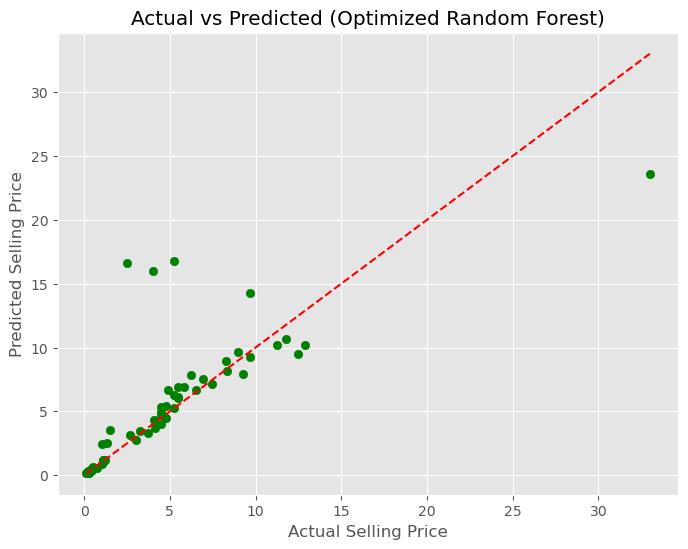

In [65]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, best_pred, color='green')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted (Optimized Random Forest)")

plt.show()

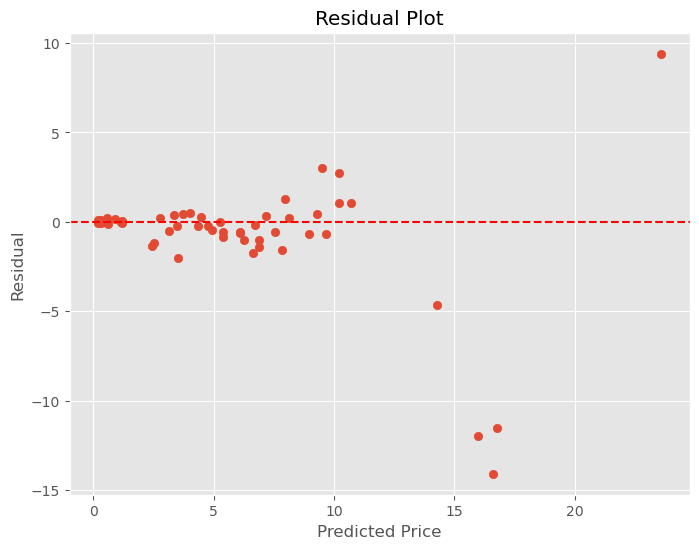

In [66]:
residuals = y_test - best_pred

plt.figure(figsize=(8,6))

plt.scatter(best_pred, residuals)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [67]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,Present_Price,9.207086e-01
3,Car_Age,5.911171e-02
1,Kms_Driven,1.401520e-02
7,Transmission_Manual,2.976288e-03
6,Seller_Type_Individual,1.738021e-03
5,Fuel_Type_Petrol,7.316806e-04
4,Fuel_Type_Diesel,7.179172e-04
2,Owner,5.346942e-07


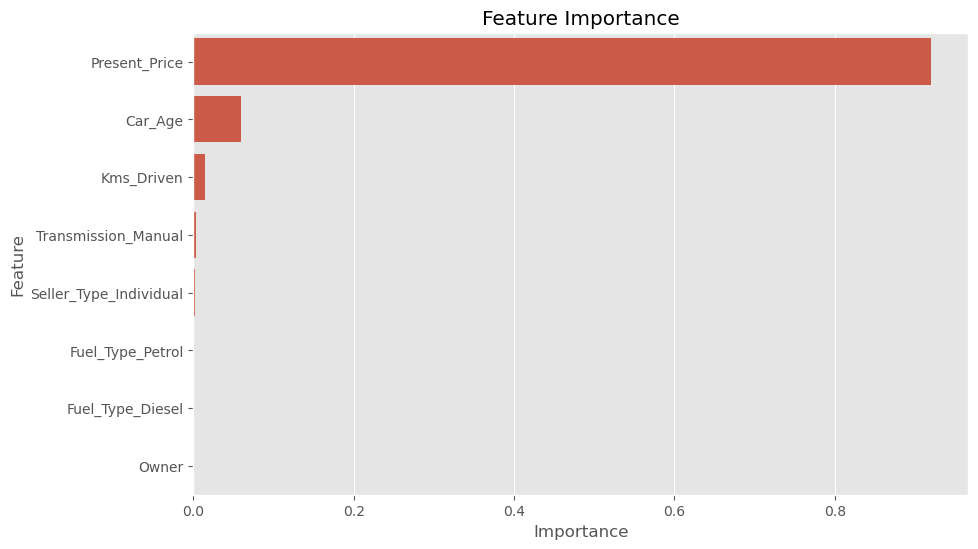

In [68]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()


Phase 8: Save Everything


In [69]:
joblib.dump(best_rf, "../data/best_car_price_model.pkl")

['../data/best_car_price_model.pkl']

In [70]:
joblib.dump(best_rf, "../data/best_car_price_model.pkl")

['../data/best_car_price_model.pkl']

In [71]:
joblib.dump(best_rf, "../data/best_car_price_model.pkl")

['../data/best_car_price_model.pkl']

In [72]:
import os

os.listdir("../data")

['best_car_price_model.pkl',
 'car data.csv',
 'car_data_cleaned.csv',
 'car_data_preprocessed.csv',
 'car_price_model.pkl',
 'scaler.pkl']

In [73]:
#feature cell created afterwards for app folder
import joblib

feature_names = list(X.columns)

joblib.dump(feature_names, "../data/features.pkl")

print("Features saved successfully!")
print(feature_names)

Features saved successfully!
['Present_Price', 'Kms_Driven', 'Owner', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual']


In [74]:
print(list(X.columns))

['Present_Price', 'Kms_Driven', 'Owner', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual']


In [75]:
import joblib

feature_names = [
    'Present_Price',
    'Kms_Driven',
    'Owner',
    'Car_Age',
    'Fuel_Type_Diesel',
    'Fuel_Type_Petrol',
    'Seller_Type_Individual',
    'Transmission_Manual'
]

joblib.dump(feature_names, "../data/features.pkl")

print("features.pkl created successfully!")

features.pkl created successfully!
